#Business Data Analytics Project- Predicting Customer Churn

## Data Loading

To improve reproducibility and ensure compatibility across different development environments, a flexible dataset path handling approach was implemented.

The code automatically detects the execution environment and searches for the dataset in multiple possible locations, including:
- GitHub repository folder structure,
- local Jupyter environments,
- Visual Studio Code environments,
- Google Colab uploads,
- and Google Drive locations.

This approach avoids hard-coded local file paths and improves portability, allowing the notebook to run consistently across different systems without requiring major code modifications.

In [1]:
from pathlib import Path
import os
import pandas as pd

IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running in Local/Jupyter/GitHub Environment")


possible_paths = [
    Path("../data/raw/telco_churn_data.csv"),
    Path("data/raw/telco_churn_data.csv"),
    Path("telco_churn_data.csv"),
    Path("/content/telco_churn_data.csv"),
    Path("/content/data/raw/telco_churn_data.csv"),
    Path("/content/drive/MyDrive/telco_churn_data.csv"),
]

# Find dataset
dataset_path = None

for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError(
        "Dataset file not found. Please upload telco_churn_data.csv to Colab "
        "or place it in data/raw/telco_churn_data.csv in the GitHub repository."
    )

print(f"Dataset loaded from: {dataset_path}")

df = pd.read_csv(dataset_path)

Running in Google Colab
Dataset loaded from: /content/drive/MyDrive/telco_churn_data.csv


After uploading the data, in otder to be sure whether the correct dataset was chosen, the below code helps to preview the dataset.

In [2]:
df.head()

,Customer ID,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,...,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
0,8779-QRDMV,No,0,1,NaN,No,0.00,No,Yes,Fiber Optic,...,34.023810,-118.156582,68701,1,5433,Competitor,Competitor offered more data,5,0,NaN
1,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Cable,...,34.044271,-118.185237,55668,1,5302,Competitor,Competitor made better offer,5,0,NaN
2,1658-BYGOY,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,...,34.108833,-118.229715,47534,1,3179,Competitor,Competitor made better offer,1,0,NaN
3,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,...,33.936291,-118.332639,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0
4,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Cable,...,33.972119,-118.020188,26265,1,2793,Price,Extra data charges,1,0,2.0


## Data Feature

Before starting the analysis, it is significant to undertand the data itself. df.columns code helps to import all the columns easily.

In [3]:
df.columns

Index(['Customer ID', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Regular Charges',
       'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Gender', 'Age', 'Under 30',
       'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Population',
       'Churn Value', 'CLTV', 'Churn Category', 'Churn Reason',
       'Total Customer Svc Requests', 'Product/Service Issues Reported',
       'Customer Satisfaction'],
      dtype='object')

* **Demographics**: Gender; Age; Under 30; Senior Citizen; Married; Dependents; Number of Dependents

* **Geographic Data**: City; Latitude; Longitude; Zip Code; Population

* **Customer Engagement**- Tenure in Months; Referred a Friend; Number of Referrals; CLTV (Customer Lifetime Value)

* **Service Usage**- Phone Service, Multiple Lines; Internet Service, Internet Type; Avg Monthly GB Download, Online Security; Online Backup; Device Protection Plan, Premium Tech Support; Streaming TV; Streaming Movies; Streaming Music; Unlimited Data

* **Financial Metrics**- Contract; Paperless Billing; Payment Method; Monthly Charge; Total Regular Charges; Total Refunds; Total Extra Data Charges; Total Long Distance Charges; Avg Monthly Long Distance Charges; Offer

* **Customer Feedback**- Customer Satisfaction; Total Customer Svc Requests; Product/Service Issues Reported; Churn Value; Churn Category; Churn Reason

* **Identifiers**-Customer ID

For a complete description of all 46 features, please refer to the Data Dictionary in Appendix

## Data Preperation

Going forward, some basic libraries have been imported

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler

df.info helps to have an overview of the data. It inclused three different data types- Object, Integer and Float. Additonally, it consist of 7042 rows and 46 unique columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Referred a Friend                  7043 non-null   object 
 2   Number of Referrals                7043 non-null   int64  
 3   Tenure in Months                   7043 non-null   int64  
 4   Offer                              3166 non-null   object 
 5   Phone Service                      7043 non-null   object 
 6   Avg Monthly Long Distance Charges  7043 non-null   float64
 7   Multiple Lines                     7043 non-null   object 
 8   Internet Service                   7043 non-null   object 
 9   Internet Type                      5517 non-null   object 
 10  Avg Monthly GB Download            7043 non-null   int64  
 11  Online Security                    7043 non-null   objec

In [6]:
unique_counts = df.nunique()
print(unique_counts)

Customer ID                          7043
Referred a Friend                       2
Number of Referrals                    12
Tenure in Months                       72
Offer                                   5
Phone Service                           2
Avg Monthly Long Distance Charges    3584
Multiple Lines                          2
Internet Service                        2
Internet Type                           3
Avg Monthly GB Download                63
Online Security                         2
Online Backup                           2
Device Protection Plan                  2
Premium Tech Support                    2
Streaming TV                            2
Streaming Movies                        2
Streaming Music                         2
Unlimited Data                          2
Contract                                3
Paperless Billing                       2
Payment Method                          3
Monthly Charge                       2298
Total Regular Charges             

Moving forward, I have checked unique values of the data and realzied that there are 1106 different variables for "City". Therefore, i have removed Lattidue, Longitude as I will be comparing customer status based on City from geographic caracteristics. Additionally, I have dropped "Customer ID" as well since every row represents unique customer and as it may not affect the churn rate.

In [7]:
df = df.drop(['Customer ID', 'Zip Code', 'Latitude', 'Longitude'], axis=1)

## Duplicates and Missing Values


Afterwards, analyzing the number of null values for all the columns

In [8]:
df.isnull().sum()

,0
Referred a Friend,0
Number of Referrals,0
Tenure in Months,0
Offer,3877
Phone Service,0
Avg Monthly Long Distance Charges,0
Multiple Lines,0
Internet Service,0
Internet Type,1526
Avg Monthly GB Download,0


From the results, Offer, Internet Type, Churn Category, Churn Reason and Customer Satisfaction have missing values. It is obvious that the higest null values belong to Customer Category, Churn Reason and Churn Satisfaction.I acknowledged that these data related to only customers who churned, so it is normal to have null values for these colums as we have high non-churned customers.

In [9]:
df['Offer'] = df['Offer'].fillna('No Offer')

In [10]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

since some of the customers are not using internet service, i am adding "No Internet" to ones who did subscribe for it. Additionally, some customers did not have any offer types and again in order to avoid missing values, i wanted to label them as "No Offer"

we do not have records of customer satisfaction for all the customers, therefore to avoid missing values, i am replacing it with not available number (-1). Scale of the satisfaction if between 1-5 and i am assigning missing values with -1. Moreover, new column will flag the model that satisfaction level is misisng

In [11]:
df['Satisfaction Missing'] = df['Customer Satisfaction'].isnull().astype(int)
df['Customer Satisfaction'] = df['Customer Satisfaction'].fillna(-1)

As Churn Category and Churn Reason belongs to customers who churned, I am replacing the data for customers who stayed with the company as "Active" and "Active Customer" for Churn Category and Churn Reason respectively.

In [12]:
df['Churn Category'] = df['Churn Category'].fillna('Active')
df['Churn Reason'] = df['Churn Reason'].fillna('Active Customer')

Checking missing values again:

In [13]:
df.isnull().sum()

,0
Referred a Friend,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0
Multiple Lines,0
Internet Service,0
Internet Type,0
Avg Monthly GB Download,0


No missing values at all. Additionally, duplicate values reviewed as well and luckly there is not any duplicated lines.

In [14]:
df.duplicated().sum()

np.int64(0)

In order to have only numeritical data, all yes & no's have been repliced by 1 (Yes) and 0 (No).

In [15]:
yes_no_cols = df.select_dtypes(include='object').columns

for col in yes_no_cols:
    if set(df[col].dropna().unique()) == {'Yes', 'No'}:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [16]:
df.head()

,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,...,City,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction,Satisfaction Missing
0,0,0,1,No Offer,0,0.00,0,1,Fiber Optic,9,...,Los Angeles,68701,1,5433,Competitor,Competitor offered more data,5,0,-1.0,1
1,1,1,8,Offer E,1,48.85,1,1,Cable,19,...,Los Angeles,55668,1,5302,Competitor,Competitor made better offer,5,0,-1.0,1
2,0,0,18,Offer D,1,11.33,1,1,Fiber Optic,57,...,Los Angeles,47534,1,3179,Competitor,Competitor made better offer,1,0,-1.0,1
3,1,1,25,Offer C,1,19.76,0,1,Fiber Optic,13,...,Inglewood,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0,0
4,1,1,37,Offer C,1,6.33,1,1,Cable,15,...,Whittier,26265,1,2793,Price,Extra data charges,1,0,2.0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Referred a Friend                  7043 non-null   int64  
 1   Number of Referrals                7043 non-null   int64  
 2   Tenure in Months                   7043 non-null   int64  
 3   Offer                              7043 non-null   object 
 4   Phone Service                      7043 non-null   int64  
 5   Avg Monthly Long Distance Charges  7043 non-null   float64
 6   Multiple Lines                     7043 non-null   int64  
 7   Internet Service                   7043 non-null   int64  
 8   Internet Type                      7043 non-null   object 
 9   Avg Monthly GB Download            7043 non-null   int64  
 10  Online Security                    7043 non-null   int64  
 11  Online Backup                      7043 non-null   int64

# Exploratory Data Analysis (EDA)

## Data Overview

Before i go into details, first wanted to understand the target valriable. And based on the results, only 26.5% of the customers churned.

In [18]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [19]:
import seaborn as sns

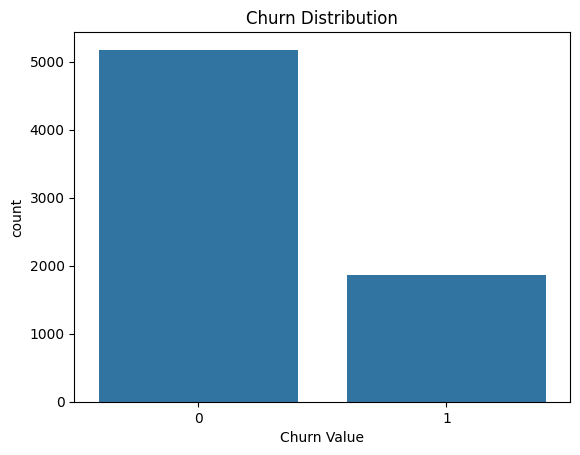

In [20]:
sns.countplot(x='Churn Value', data=df)
plt.title('Churn Distribution')
plt.show()

In [21]:
df['Churn Value'].value_counts(normalize=True) * 100

,proportion
Churn Value,
0,73.463013
1,26.536987


Furthermore, to identifying the numerical and categorical variables in the dataset the below code  prepared. Because different variable types require different visualization and analytical techniques.

In [22]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numeric columns:
['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Monthly Charge', 'Total Regular Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Churn Value', 'CLTV', 'Total Customer Svc Requests', 'Product/Service Issues Reported', 'Customer Satisfaction', 'Satisfaction Missing']

Categorical columns:
['Offer', 'Internet Type', 'Contract', 'Payment Method', 'Gender', 'City', 'Churn Category', 'Churn Reason']


Moving forward, i would like to check which cities has higher churn rate. in order to avoid misleading, i first checked the count of customers per cities and then weanted to check churn rate for the cities that has at least 50 customers.

In [23]:
import matplotlib.pyplot as plt

In [24]:
city_churn = df.groupby('City')['Churn Value'].mean().sort_values(ascending=False).head(10)

In [25]:
city_counts = df['City'].value_counts()
city_counts.head(10)

,count
City,
Los Angeles,293
San Diego,285
San Jose,112
Sacramento,108
San Francisco,104
Fresno,61
Long Beach,60
Oakland,52
Escondido,51


In [26]:
valid_cities = city_counts[city_counts > 50].index

In [27]:
city_churn = df[df['City'].isin(valid_cities)] \
    .groupby('City')['Churn Value'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

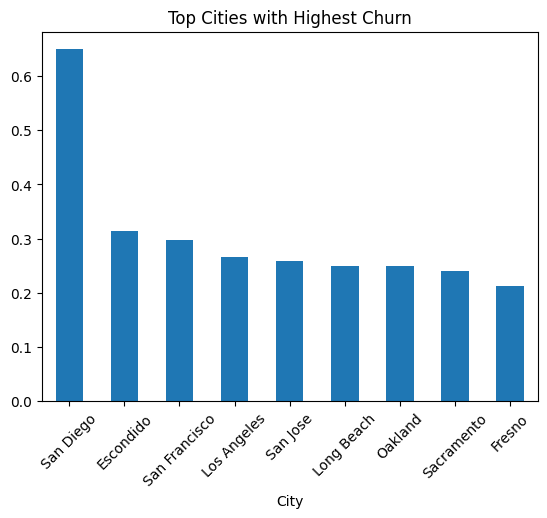

In [28]:
city_churn.plot(kind='bar')
plt.title('Top Cities with Highest Churn')
plt.xticks(rotation=45)
plt.show()

The Results confirms that the highest churn rate is based in San Diego followed by Escondido.

It is also worth to mention that, San Diego is also the second biggest city in terms of customer count. This may highight insightful issue, hence chrun reasons should be anlayzed deeply.

In [29]:
sd_churn = df[(df['City'] == 'San Diego') & (df['Churn Value'] == 1)]

In [30]:
sd_reason_pct = sd_churn['Churn Reason'].value_counts(normalize=True) * 100
print(sd_reason_pct)

Churn Reason
Competitor made better offer        78.918919
Don't know                           8.108108
Attitude of support person           4.324324
Competitor had better devices        3.243243
Poor expertise of online support     1.081081
Attitude of service provider         1.081081
Product dissatisfaction              1.081081
Long distance charges                1.081081
Network reliability                  0.540541
Lack of self-service on Website      0.540541
Name: proportion, dtype: float64


In [31]:
rest_churn = df[(df['City'] != 'San Diego') & (df['Churn Value'] == 1)]

In [32]:
rest_reason_pct = rest_churn['Churn Reason'].value_counts(normalize=True) * 100

In [33]:
comparison_df = pd.DataFrame({
    'San Diego %': sd_reason_pct,
    'Rest of Dataset %': rest_reason_pct
}).fillna(0)

comparison_df = comparison_df.sort_values(by='San Diego %', ascending=False)
print(comparison_df.head(10))

                                  San Diego %  Rest of Dataset %
Churn Reason                                                    
Competitor made better offer        78.918919           9.798100
Don't know                           8.108108           6.828979
Attitude of support person           4.324324          12.589074
Competitor had better devices        3.243243          18.230404
Attitude of service provider         1.081081           5.463183
Product dissatisfaction              1.081081           4.453682
Poor expertise of online support     1.081081           1.722090
Long distance charges                1.081081           3.681710
Network reliability                  0.540541           4.216152
Lack of self-service on Website      0.540541           1.662708


## Customer Satisfaction Analysis

In order to compare customer satisfaciton in high chruned cities vs others, i have created the below chart. It clearly shows that low satisfaction rates are more common for high churn cities.

/tmp/ipykernel_41843/1707685550.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


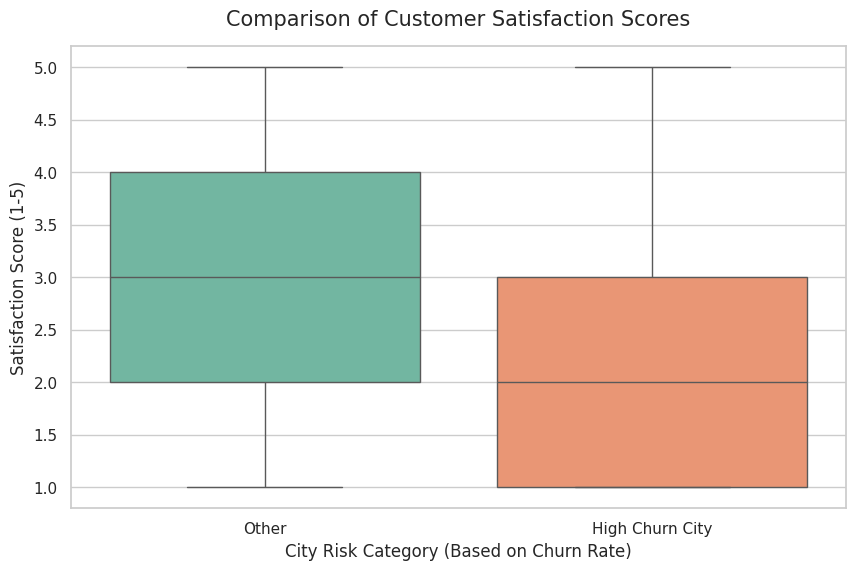

In [34]:
city_churn = df.groupby('City')['Churn Value'].mean()

high_churn_cities = city_churn[city_churn > 0.5].index

df['City_Category'] = df['City'].apply(
    lambda x: 'High Churn City' if x in high_churn_cities else 'Other'
)

df_plot = df[df['Customer Satisfaction'] != -1]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x='City_Category',
    y='Customer Satisfaction',
    palette='Set2'
)

plt.title('Comparison of Customer Satisfaction Scores', fontsize=15, pad=15)
plt.xlabel('City Risk Category (Based on Churn Rate)', fontsize=12)
plt.ylabel('Satisfaction Score (1-5)', fontsize=12)

plt.show()

Moving forward, i analayzed the date based on contract type. From the results, the highest churning portion belongs to Mont-toMonth contract while the smallest portion belongs to Twwo-year contract holders.

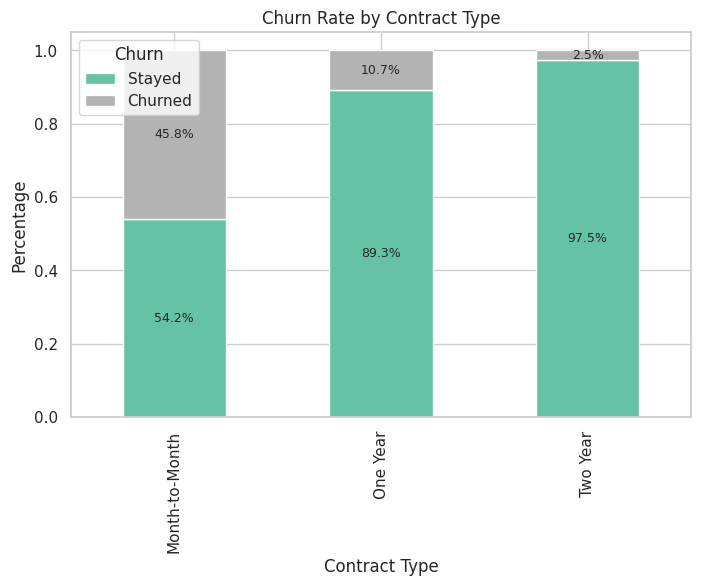

In [35]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Value'],
    normalize='index'
)

ax = contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap='Set2'
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn', labels=['Stayed', 'Churned'])


for i, contract in enumerate(contract_churn.index):
    cumulative = 0
    for j, value in enumerate(contract_churn.loc[contract]):
        ax.text(
            i,
            cumulative + value/2,
            f"{value*100:.1f}%",
            ha='center',
            va='center',
            fontsize=9
        )
        cumulative += value

plt.show()

service types have been analyzed to see if there is any connection for chrun rate.

/tmp/ipykernel_41843/868713768.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn Rate', y='Service', data=service_df, palette='coolwarm')


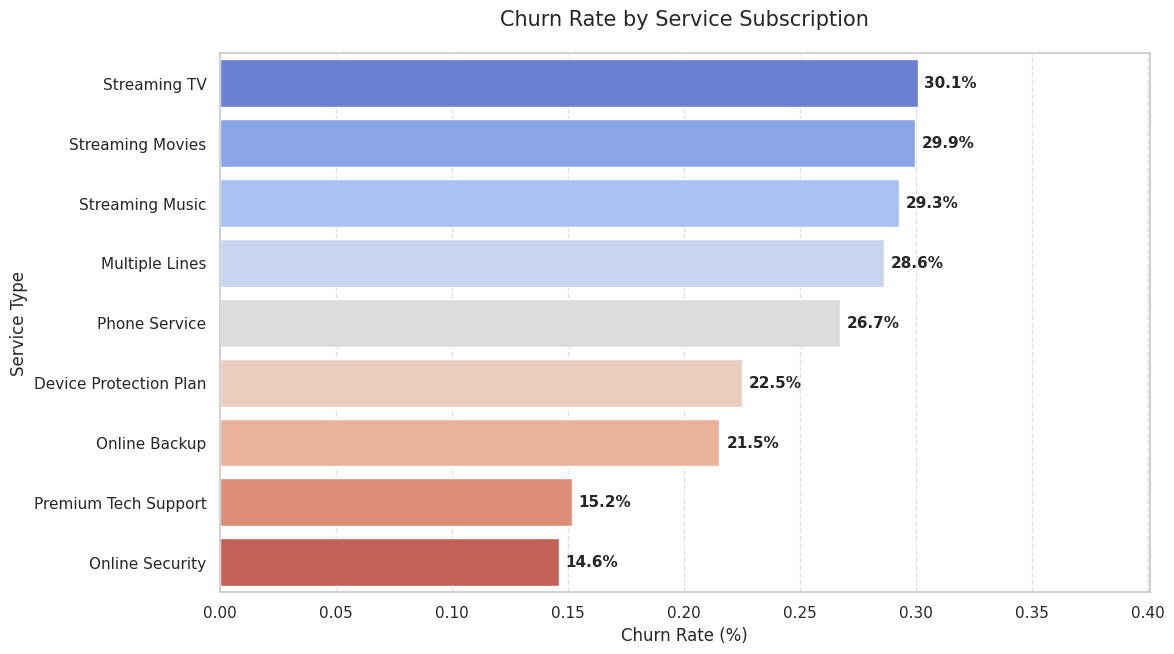

In [36]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Online Security',
    'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music'
]

service_churn_rates = {}
for col in service_cols:

    rate = df[df[col] == 1]['Churn Value'].mean()
    service_churn_rates[col] = rate

service_df = pd.DataFrame(list(service_churn_rates.items()), columns=['Service', 'Churn Rate'])
service_df = service_df.sort_values(by='Churn Rate', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Churn Rate', y='Service', data=service_df, palette='coolwarm')

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1%}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Churn Rate by Service Subscription', fontsize=15, pad=20)
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Service Type', fontsize=12)
plt.xlim(0, max(service_df['Churn Rate']) + 0.1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [37]:
service_cols = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

df['Total_Services'] = df[service_cols].sum(axis=1)

In [38]:
service_churn = df.groupby('Total_Services')['Churn Value'].mean()

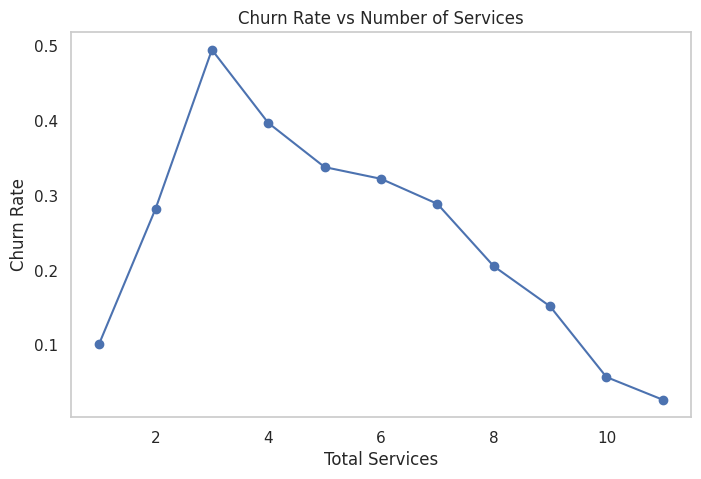

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(service_churn.index, service_churn.values, marker='o')

plt.title('Churn Rate vs Number of Services')
plt.xlabel('Total Services')
plt.ylabel('Churn Rate')

plt.grid()
plt.show()

Here, i explored if having more services is connected to churn rate or not.

## Analysis of Monthly Spending and Tenure

Moreover, Monthly Charge Distrubtion has been analyzed and based on the results, churn possibility is higher if monthy spending is high.

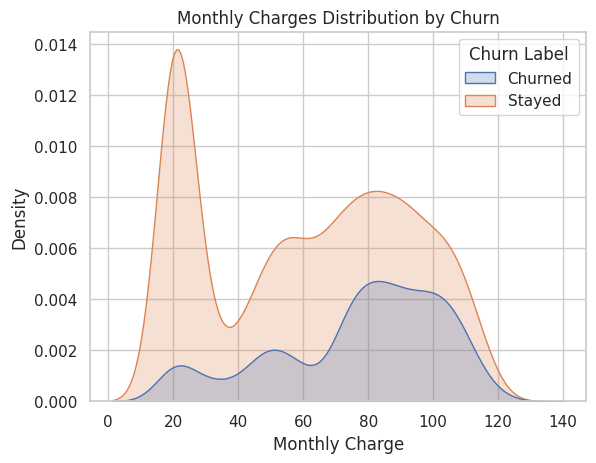

In [40]:
df['Churn Label'] = df['Churn Value'].map({0: 'Stayed', 1: 'Churned'})

sns.kdeplot(data=df, x='Monthly Charge', hue='Churn Label', fill=True)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charge')
plt.ylabel('Density')
plt.show()

Tenure vs Churn has been also analyzed. Results shows that customers having high tenure tend to stay, while short-term tenure has a tendency to chrun. However, some customers having 70+ month of tenure also churned which confirms that customer behavior is not entirely homogenus.

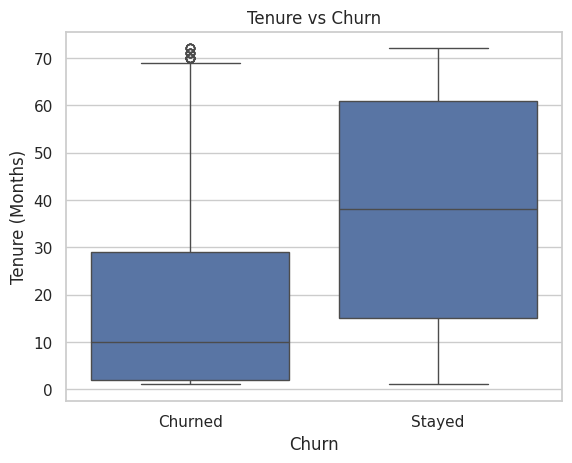

In [41]:
sns.boxplot(x='Churn Label', y='Tenure in Months', data=df)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

connection between tenure and monthly charges has been also analyzed.

According to the chart, the following patterns have been established:

-	Low tenure+ High Charges -> High Churn

-	High tenure+ medium charges -> Less Churn

-	High tenure+ high charges -> les Churn

Therefore, the more customers stay is lower the way they care about the prices.


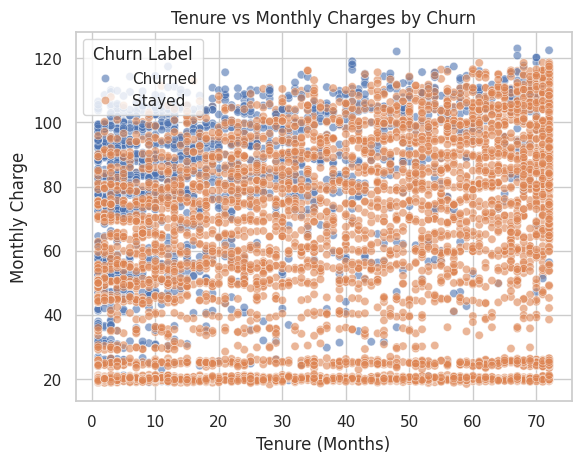

In [42]:
sns.scatterplot(
    data=df,
    x='Tenure in Months',
    y='Monthly Charge',
    hue='Churn Label',
    alpha=0.6
)

plt.title('Tenure vs Monthly Charges by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charge')
plt.show()

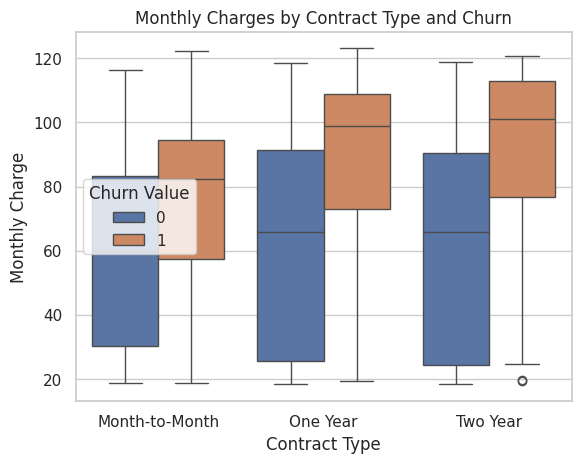

In [43]:
sns.boxplot(data=df, x='Contract', y='Monthly Charge', hue='Churn Value')

plt.title('Monthly Charges by Contract Type and Churn')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charge')

plt.show()

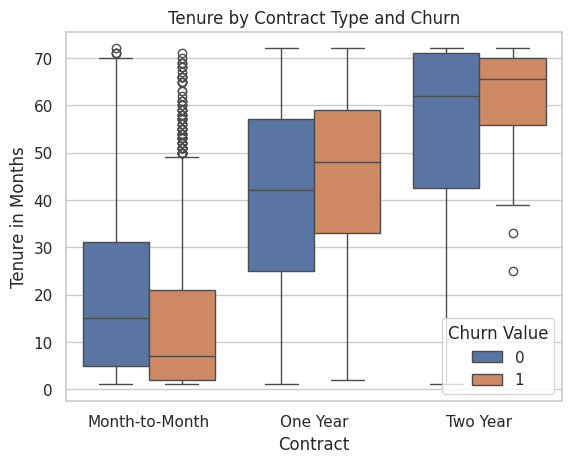

In [44]:
sns.boxplot(data=df, x='Contract', y='Tenure in Months', hue='Churn Value')

plt.title('Tenure by Contract Type and Churn')
plt.show()

## Analysis of Demographic Factors

I have also analyzed age vs churn to see the potential cause of churn. However, according to the results, there is only slight diifference on the median. IN conclusion, age is not a sole determinant of churn.

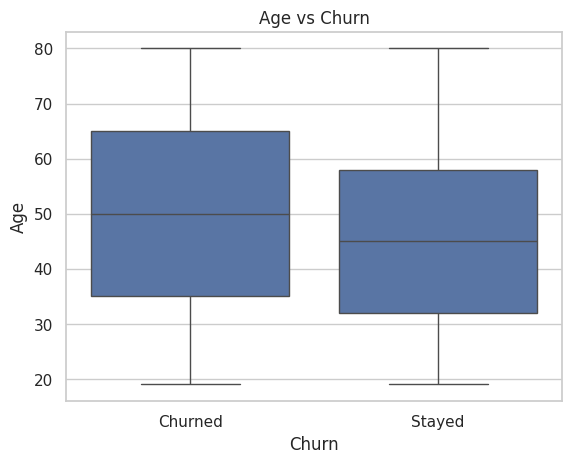

In [45]:
sns.boxplot(x='Churn Label', y='Age', data=df)

plt.title('Age vs Churn')
plt.xlabel('Churn')
plt.ylabel('Age')

plt.show()

Churn analysis based on Genders also analyzed. Results suggests that there is no connection with age and churn rate.

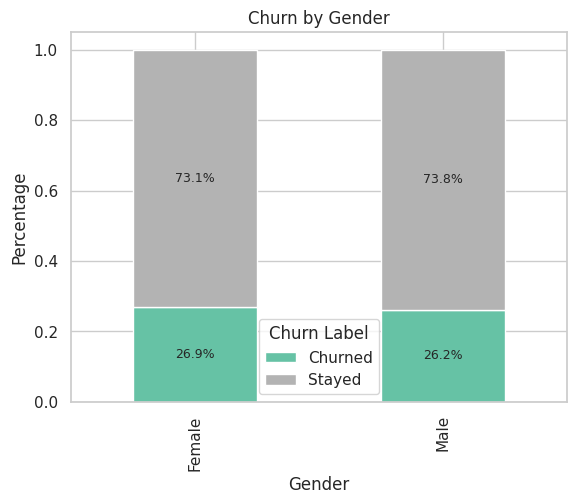

In [46]:
gender_churn = pd.crosstab(df['Gender'], df['Churn Label'], normalize='index')

ax = gender_churn.plot(kind='bar', stacked=True, colormap='Set2')

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')

for i, gender in enumerate(gender_churn.index):
    cumulative = 0
    for j, value in enumerate(gender_churn.loc[gender]):
        ax.text(
            i,
            cumulative + value/2,
            f"{value*100:.1f}%",
            ha='center',
            va='center',
            fontsize=9
        )
        cumulative += value

plt.show()

## Correlation Analysis

correlation analysis was conducted to have an overview of the dataset and check if  variables has a connection with target variable.

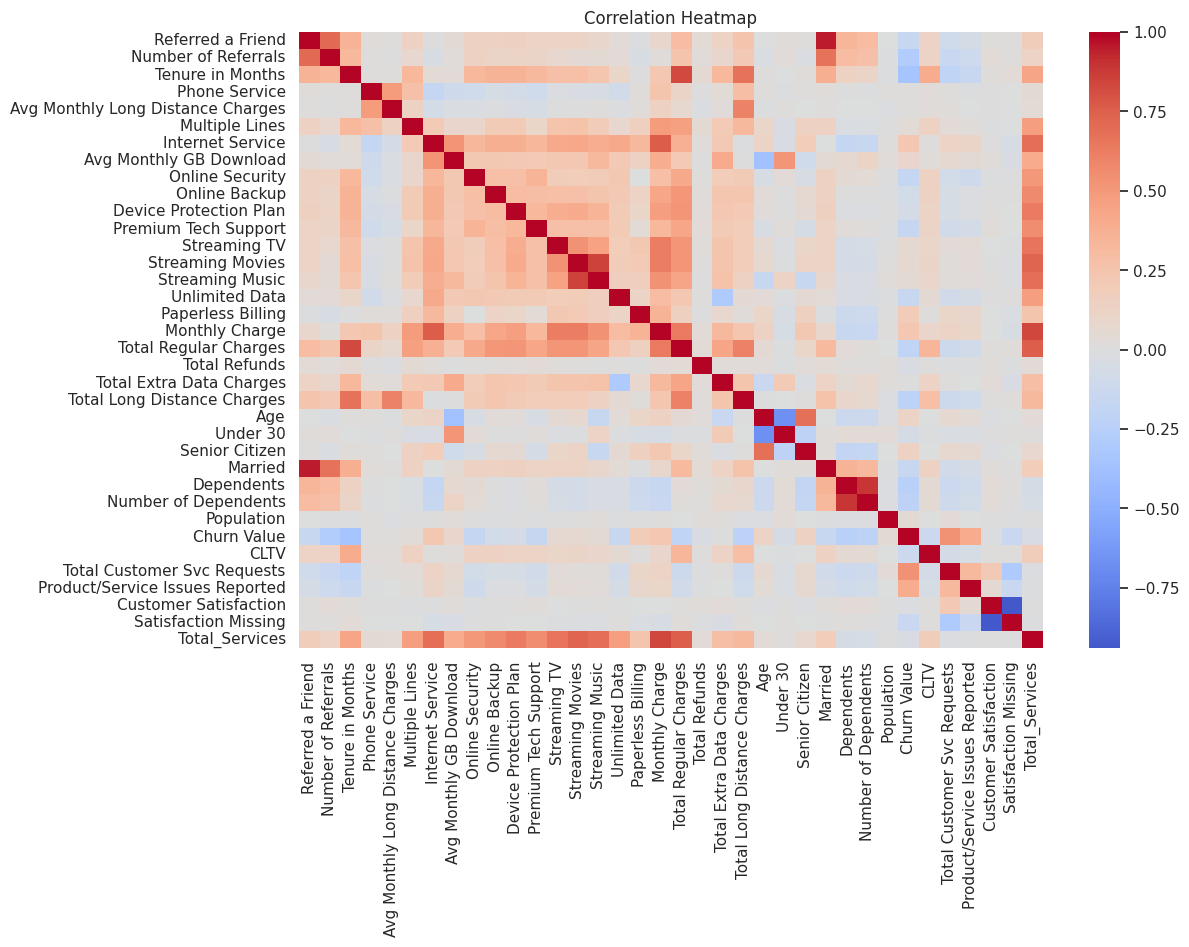

In [47]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

## Outlier Analysis

Moving forward, outlier analysis was conducted too.

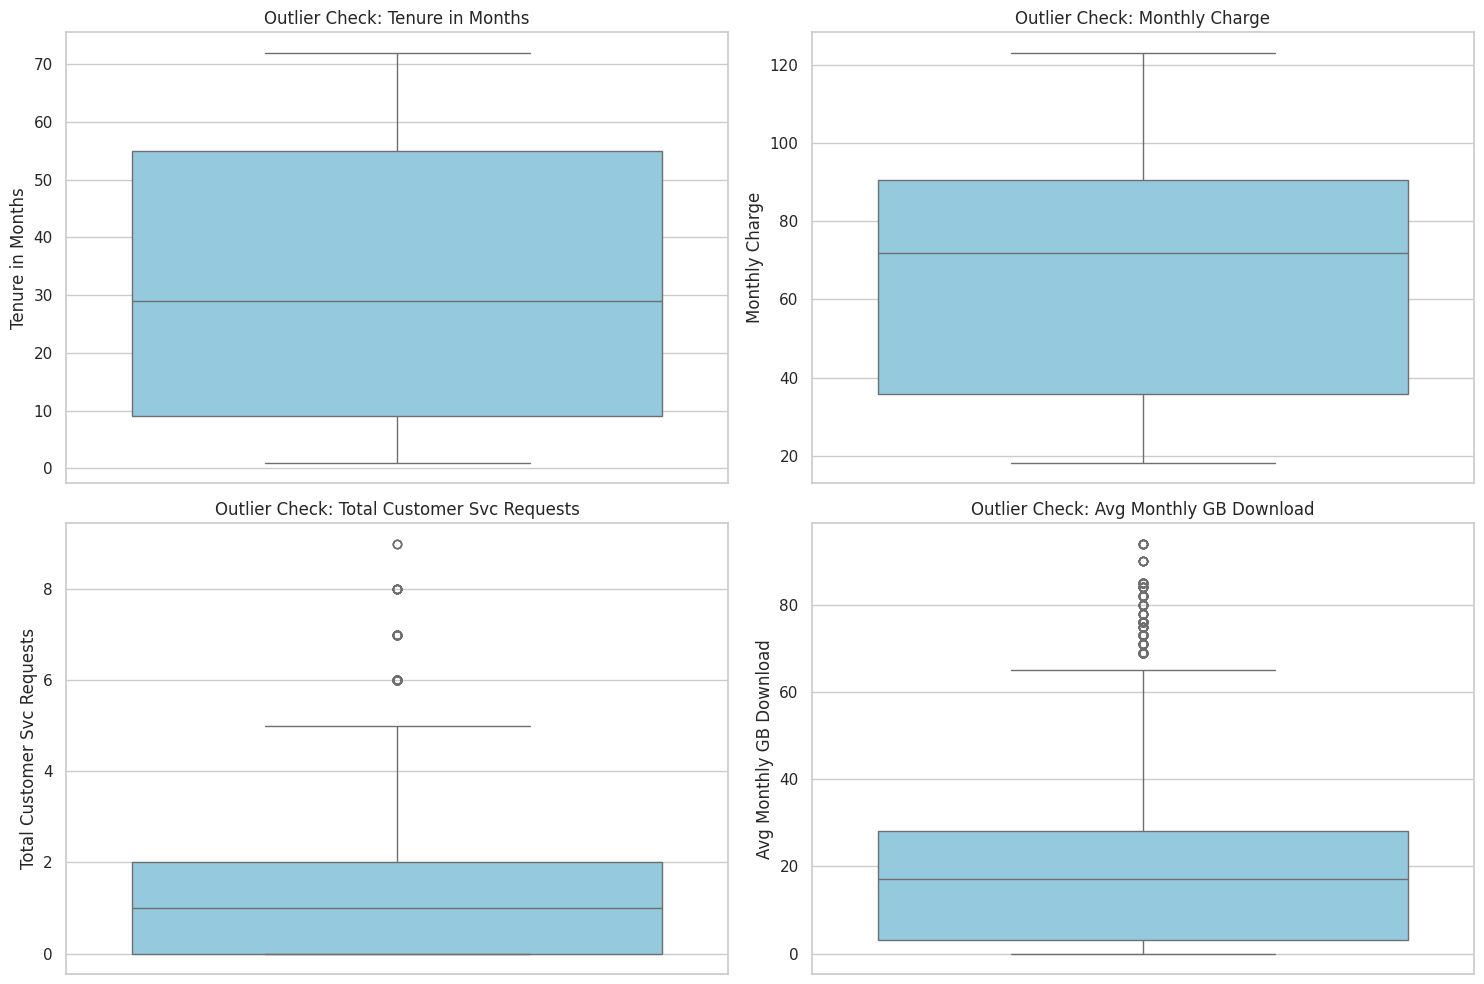

In [48]:
num_cols = ['Tenure in Months', 'Monthly Charge', 'Total Customer Svc Requests', 'Avg Monthly GB Download']

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

Lastly, checking statistical summary of the dataset:

In [49]:
df.describe()

,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Avg Monthly GB Download,Online Security,Online Backup,...,Dependents,Number of Dependents,Population,Churn Value,CLTV,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction,Satisfaction Missing,Total_Services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.457476,1.951867,32.386767,0.903166,22.958954,0.421837,0.783331,21.110890,0.286668,0.344881,...,0.231010,0.468692,22139.603294,0.265370,4400.295755,1.338776,0.308107,0.043021,0.739600,4.883430
std,0.498224,3.001199,24.542061,0.295752,15.448113,0.493888,0.412004,20.948471,0.452237,0.475363,...,0.421508,0.962802,21152.392837,0.441561,1183.057152,1.430471,0.717514,1.871245,0.438884,2.819358
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,11.000000,0.000000,2003.000000,0.000000,0.000000,-1.000000,0.000000,1.000000
25%,0.000000,0.000000,9.000000,1.000000,9.210000,0.000000,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,2344.000000,0.000000,3469.000000,0.000000,0.000000,-1.000000,0.000000,2.000000
50%,0.000000,0.000000,29.000000,1.000000,22.890000,0.000000,1.000000,17.000000,0.000000,0.000000,...,0.000000,0.000000,17554.000000,0.000000,4527.000000,1.000000,0.000000,-1.000000,1.000000,5.000000
75%,1.000000,3.000000,55.000000,1.000000,36.395000,1.000000,1.000000,28.000000,1.000000,1.000000,...,0.000000,0.000000,36125.000000,1.000000,5380.500000,2.000000,0.000000,1.000000,1.000000,7.000000
max,1.000000,11.000000,72.000000,1.000000,49.990000,1.000000,1.000000,94.000000,1.000000,1.000000,...,1.000000,9.000000,105285.000000,1.000000,6500.000000,9.000000,6.000000,5.000000,1.000000,11.000000


# Data Preparation and Splitting

I have removed some variables from predictive modeling. Since they describe information available only after customers already churned, removing them will help to avoid data leakage and unaccuracy. Moreover, high-cardinality variables like City was also removed to support robustness and interpretability.

In [50]:
df_model = df.drop([
    'Churn Label',
    'Churn Category',
    'Churn Reason',
    'City',
    'Total_Services'
], axis=1)

# here, i converted categorical variables to numeric

df_model = pd.get_dummies(df_model, drop_first=True)

# y is defined as target and x defined as features

X = df_model.drop('Churn Value', axis=1)
y = df_model['Churn Value']

In [51]:
print(X.shape)
print(y.shape)

(7043, 48)
(7043,)


The dataset was divided into 2 parts- train (80%) and test (20%)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print(X_train.shape)
print(X_test.shape)

(5634, 48)
(1409, 48)


## Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

All the variables have been scaled to the same level

# Logistic Regression Model

In [55]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

Logistic Regression model has been established. model has been trained with splitted training data

In [56]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.936124911284599
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1035
           1       0.90      0.86      0.88       374

    accuracy                           0.94      1409
   macro avg       0.92      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409



model achived around 94% from all the metrics.

# Random Forest

Going forward, Random Forest model has been created and with that it has been again trained by training data

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, classification_report

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.9162526614620298
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1035
           1       0.90      0.78      0.83       374

    accuracy                           0.92      1409
   macro avg       0.91      0.87      0.89      1409
weighted avg       0.92      0.92      0.91      1409



Based on the results, model achived 91.62% accuracy and about 92% weighted average for all the metrics. Which provided lower results from LR model.

## Hyperparameter Tuning

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=1)

### Tuned Model Evaluation

In [60]:
best_rf = rf_random.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, classification_report

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned RF Accuracy: 0.9112845990063875
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1035
           1       0.89      0.76      0.82       374

    accuracy                           0.91      1409
   macro avg       0.90      0.86      0.88      1409
weighted avg       0.91      0.91      0.91      1409



tuning model increased the model accuracy a tiny bit and reached to 91.12%

# Gradinent Boosting Model

The Gradient Boosting algorithm was also applied to extend model comparison.

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score, classification_report

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9389638041163946
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1035
           1       0.93      0.83      0.88       374

    accuracy                           0.94      1409
   macro avg       0.94      0.91      0.92      1409
weighted avg       0.94      0.94      0.94      1409



As obvious from the results, Gradinent Boosting reached the highet rate of accuracy at 93.89%

# Model Comparison

In [64]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.936125,0.898876,0.855615,0.876712,0.974388
1,Random Forest,0.916253,0.895062,0.775401,0.830946,0.962714
2,Gradient Boosting,0.938964,0.928571,0.834225,0.878873,0.976907


Clearly, the highest rates belong to Gradinent Boosting which confirms the quality of the model.

## Feature Importance

48
48


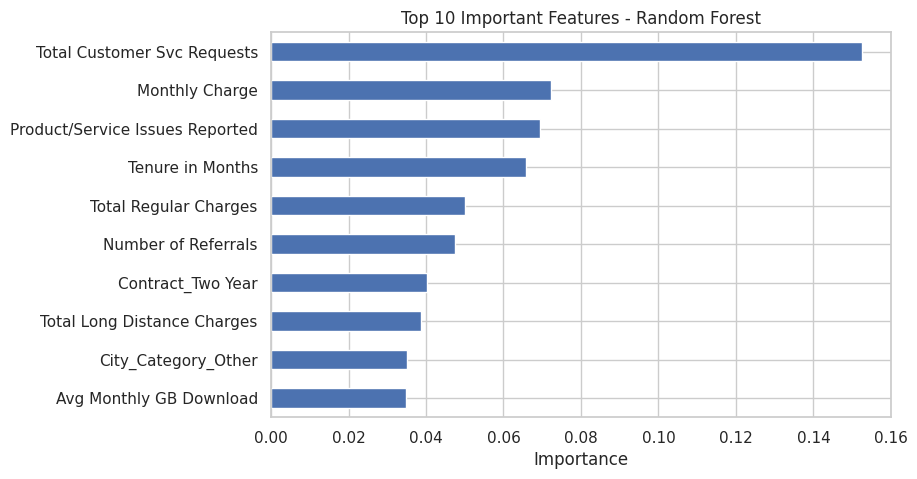

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

print(len(rf_model.feature_importances_))
print(len(X_train.columns))

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

top_features.plot(kind='barh', figsize=(8,5))

plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()

plt.show()

Feature Importance have been analyzed and based on the results, Total SVC requests, Tenure and Monthly Charges have the higest influence on customer decision.

## Confusion Matrix Analysis

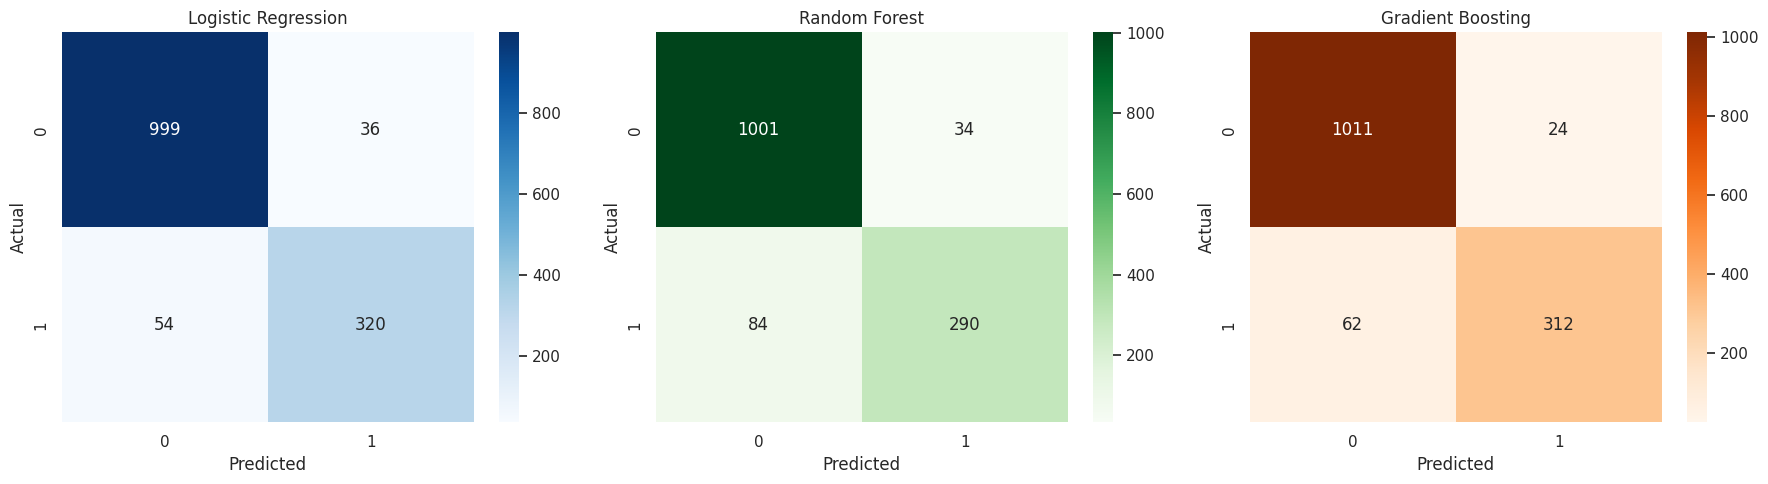

In [67]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Gradient Boosting')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Roc-Auc

In [68]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Logistic ROC-AUC: 0.9743883851300732
Random Forest ROC-AUC: 0.9627140974967062
Gradient Boosting ROC-AUC: 0.9769071792089693


Again Gradinent Boosting Received the higest rate.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


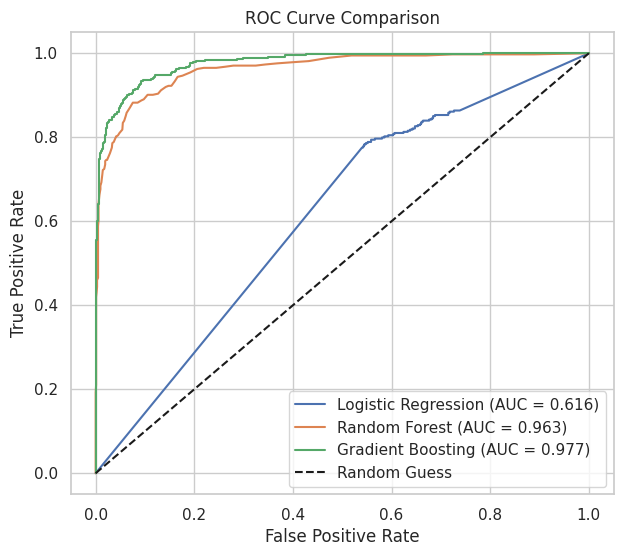

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(7,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Appendix

## Data Dictionary

* **Customer ID**- Unique Identifier of the customer
* **Referred a Friend**- Shows whether the customer has previously referred any acquaintances to the company.
* **Number of Referrals**- the number of people that were referred to by the customer by today
* **Tenure in Months**- the total number of months the customer has spent with the client as of the end of the quarter
* **Offer**- states the last marketing offer (if any) that the customer has accepted
* **Phone Service**- states whether the customer has a home phone service subscription with the company
* **Avg Monthly Long Distance Charges**- customer's average long-distance charges calculated as of the end of the quarter
*  **Multiple Lines**- indicates whether the customer has more than one phone line subscription with the company
* **Internet Service**- shows whether the customer has an internet service subscrption with the company
* **Internet Type**- specifies the type of internet service the customer subscribes to

* **Avg Monthly Long Distance Charges**- Displays the customer's average download volume in gigabytes as of the end of the quarter

* **Online Security**- indicates whether the customer is subscribed to an additional online security service provided by the company

* **Online Backup**- indicates whether the customer is subscribed to an additional online backup service provided by the company

* **Device Protection Plan**- displays whether the customer has subscribed to an additional device protection plan for their internet equipment

* **Premium Tech Support**- shows whether the customer has subscribed to an additional technical support plan from the company that reduces waiting times

* **Streaming TV** - indicates whether the customer is using their internet service to watch television programs from a third-party source
* **Streaming Movies**- shows whether the customer is using their internet service to watch movies from a third-party provider
* **Streaming Musin** - demonstrates whether the customer is using the internet service to stream music from a third-party provider.
* **Unlimited data**- Indicates whether the customer pays an additional monthly fee for unlimited data uploads/downloads
* **Contract** - Customers current contract type
* **Paperless Billing**- if customer is registered for this service
* **Payment Method**- the way customer pay the bills
* **Monthly Charge**- customer's total monthly payment for all services provided by the company.
* **Total Regular Charges**- total regular charges, excluding additional charges
* **Total Refunds**- total refunds the custpmer received
* **Total Extra Charges**- total cost of additional data downloads beyond what is specified in the customer's plan
* **Gender**- Customer's Gender
* **Total Long Distance Charges**- total long-distance call costs exceeding what is stated in the client's plan

* **Under 30**- if customer's age is under 30
* **Senior Citizen**- if cutsomer is 65 or older
* **Married**- if custoemr is married
* **Dependents**-customer lives with any dependents like dependents could be children, parents
* **Number of Dependent**- number of dependents that live with the customer
* **City**- Customers residence city
* **Zip code**- zip code of primary address
* **Latitude**- latitude of primary address
* **Longitude**- Longitude of primary address
* **Population**- Current population of the primary city
* **Churn value**- 1- customer churned this quarter. 0- customer remained with the company
* **CLTV**- Customer Lifetime Value
* **CHurn Category**- high level reason category for churning
* **Churn Reason**- reason for churning
* **Total Customer SVC requests**- Number of times the customer contacted customer service in the past quarter
* **Product/Service Issues Reported**- Number of times the customer reported an issue with a product or service in the past quarter
* **Customer Satisfaction**-customer’s overall satisfaction rate from 1 (Very Unsatisfied) to 5 (Very Satisfied) collected on


## GitHUB Repository

GitHub repository:  https://github.com/IamAydans/Customer-Churn-Prediction-